<a href="https://colab.research.google.com/github/Yaswanthgangireddy/Sales-Forecasting-Demand-Intelligence-System/blob/main/Sales_Forecasting_Demand_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extract the ZIP Files

In [7]:
import zipfile

# Extract Superstore dataset
with zipfile.ZipFile('/content/archive (24).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/superstore')

# Extract Video Game dataset
with zipfile.ZipFile('/content/archive (25).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/vgsales')

print("Extraction completed!")

Extraction completed!


Check the Extracted Files

In [8]:
import os

print("Superstore Files:")
print(os.listdir('/content/superstore'))

print("\nVideo Game Files:")
print(os.listdir('/content/vgsales'))

Superstore Files:
['train.csv']

Video Game Files:
['vgsales.csv']


Install Required Libraries

In [9]:
!pip install prophet
!pip install xgboost

Import Libraries

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

import xgboost as xgb

Load Both Datasets

In [11]:
superstore = pd.read_csv('/content/superstore/train.csv')
games = pd.read_csv('/content/vgsales/vgsales.csv')

Verify the Data

Run:

In [12]:
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


TASK 1

Load the Datasets

In [14]:
# ==============================
# Import Required Libraries
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option('display.max_columns', None)

# Plot Style
plt.style.use('ggplot')

Load Both Datasets

In [15]:
# ==============================
# Load Datasets
# ==============================

superstore = pd.read_csv('/content/superstore/train.csv')
vgsales = pd.read_csv('/content/vgsales/vgsales.csv')

Superstore Dataset

In [16]:
print("="*70)
print("SUPERSTORE DATASET")
print("="*70)

display(superstore.head())

print("\nShape:", superstore.shape)

print("\nColumns:")
display(superstore.columns)

print("\nData Types:")
superstore.info()

print("\nStatistical Summary:")
display(superstore.describe(include='all'))

SUPERSTORE DATASET


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Shape: (9800, 18)

Columns:


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


Video Game Dataset

In [17]:
print("="*70)
print("VIDEO GAME SALES DATASET")
print("="*70)

display(vgsales.head())

print("\nShape:", vgsales.shape)

print("\nColumns:")
display(vgsales.columns)

print("\nData Types:")
vgsales.info()

print("\nStatistical Summary:")
display(vgsales.describe(include='all'))

VIDEO GAME SALES DATASET


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



Shape: (16598, 11)

Columns:


Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB

Statistical Summary:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


Check Missing Values

In [18]:
print("Superstore Missing Values")
display(superstore.isnull().sum())

print("\nVideo Game Missing Values")
display(vgsales.isnull().sum())

Superstore Missing Values


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Video Game Missing Values


,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


Check Duplicate Records

In [19]:
print("Superstore Duplicate Rows :", superstore.duplicated().sum())

print("Video Game Duplicate Rows :", vgsales.duplicated().sum())

Superstore Duplicate Rows : 0
Video Game Duplicate Rows : 0


Convert Date Columns

In [20]:
superstore['Order Date'] = pd.to_datetime(
    superstore['Order Date'],
    format='%d/%m/%Y'
)

superstore['Ship Date'] = pd.to_datetime(
    superstore['Ship Date'],
    format='%d/%m/%Y'
)

In [21]:
superstore[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


Create Time Features

In [22]:
# ==============================
# Feature Engineering
# ==============================

superstore['Year'] = superstore['Order Date'].dt.year

superstore['Month'] = superstore['Order Date'].dt.month

superstore['Month Name'] = superstore['Order Date'].dt.month_name()

superstore['Week'] = superstore['Order Date'].dt.isocalendar().week

superstore['Day'] = superstore['Order Date'].dt.day_name()

superstore['Quarter'] = superstore['Order Date'].dt.quarter

Create Season Column

In [23]:
season_map = {
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'
}

superstore['Season'] = superstore['Month'].map(season_map)

Calculate Shipping Time

In [24]:
superstore['Shipping Days'] = (
    superstore['Ship Date'] -
    superstore['Order Date']
).dt.days

In [25]:
superstore[['Order Date','Ship Date','Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


Aggregate Daily Sales into Weekly & Monthly Totals

Weekly Sales

In [26]:
weekly_sales = (
    superstore
    .groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Monthly Sales

In [27]:
monthly_sales = (
    superstore
    .groupby(pd.Grouper(key='Order Date', freq='M'))['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Save Clean Dataset

In [28]:
superstore.to_csv("clean_superstore.csv", index=False)

TASK 1.1 - Which Product Category Generates the Highest Total Revenue?

In [29]:
# Total sales by category
category_sales = (
    superstore.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


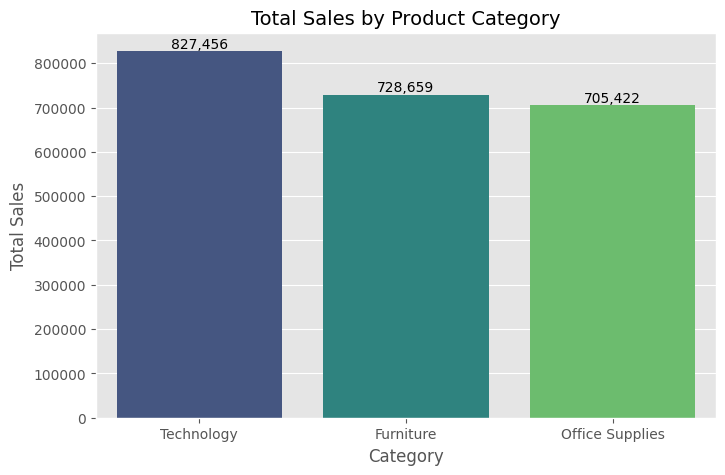

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette='viridis'
)

plt.title("Total Sales by Product Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

for i, value in enumerate(category_sales.values):
    plt.text(i, value, f"{value:,.0f}", ha='center', va='bottom')

plt.show()

TASK 1.2 - Which Region Has the Most Consistent Sales Growth?

In [31]:
monthly_region_sales = (
    superstore.groupby([
        pd.Grouper(key='Order Date', freq='M'),
        'Region'
    ])['Sales']
    .sum()
    .reset_index()
)

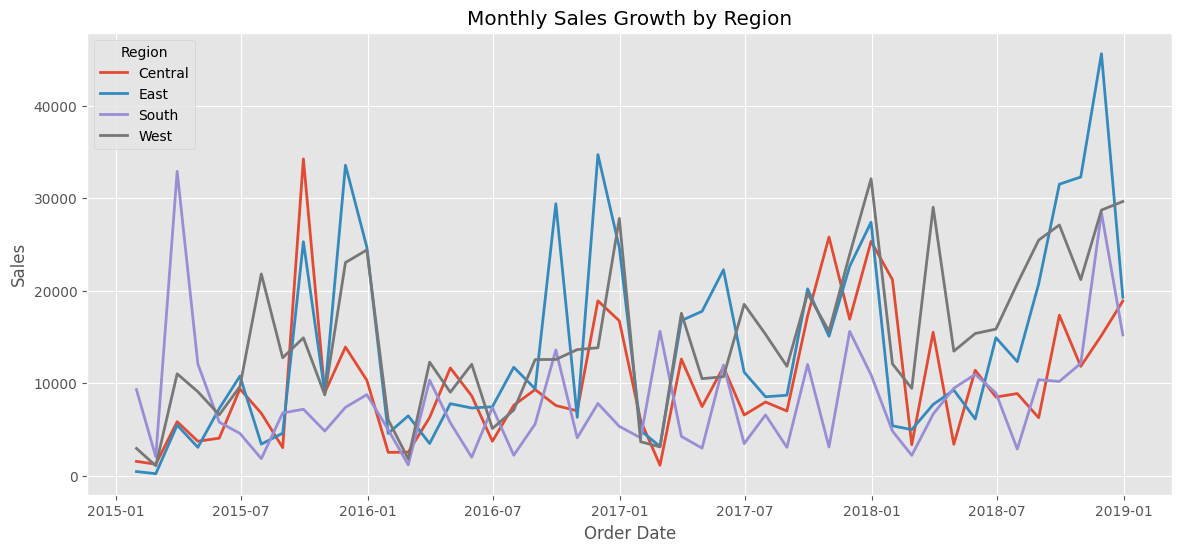

In [32]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_region_sales,
    x='Order Date',
    y='Sales',
    hue='Region',
    linewidth=2
)

plt.title("Monthly Sales Growth by Region")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend(title="Region")
plt.show()

TASK 1.3 - Average Shipping Time

In [33]:
print("Average Shipping Time:",
      round(superstore['Shipping Days'].mean(),2),
      "days")

Average Shipping Time: 3.96 days


In [34]:
shipping_region = (
    superstore.groupby('Region')['Shipping Days']
    .mean()
    .sort_values()
)

shipping_region

,Shipping Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


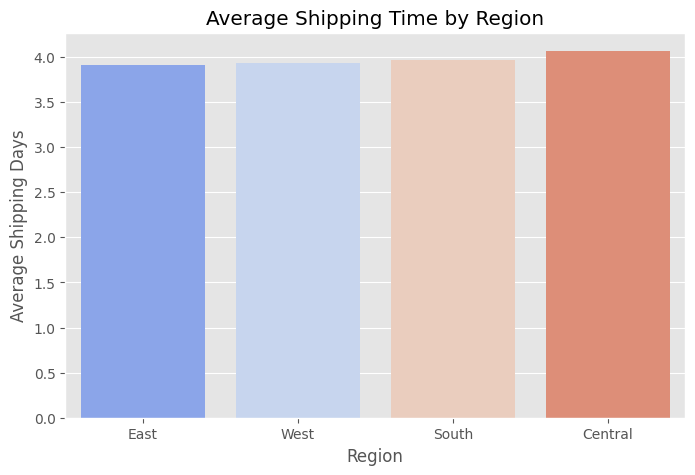

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette='coolwarm'
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

TASK 1.4 - Do Certain Months Consistently Have Higher Sales?

In [36]:
monthly_sales = (
    superstore.groupby(['Year','Month'])['Sales']
    .sum()
    .reset_index()
)

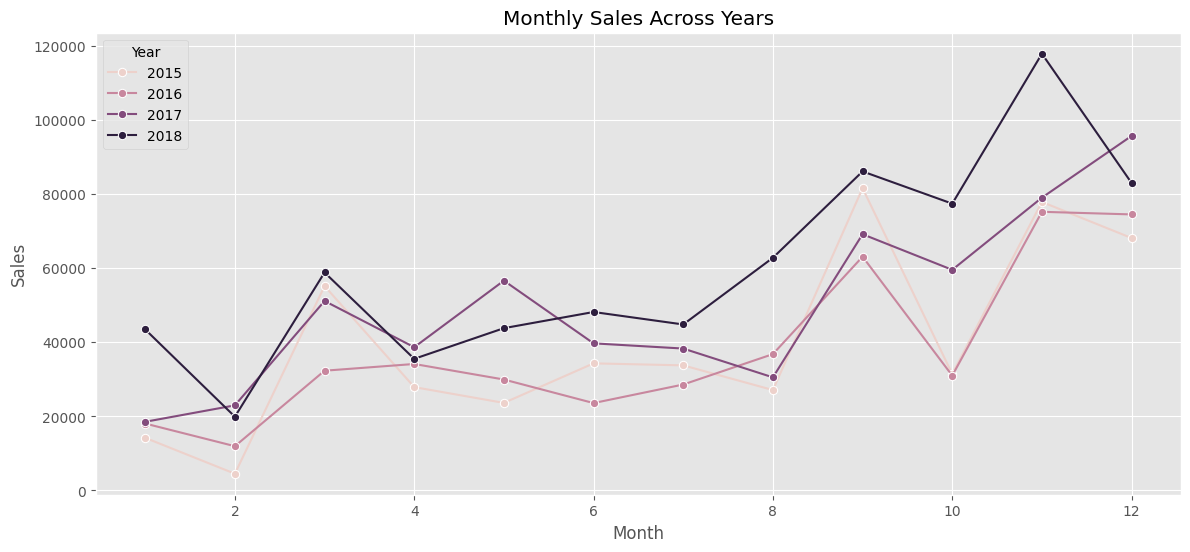

In [37]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    hue='Year',
    marker='o'
)

plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

TASK 2

Create Monthly Sales Time Series

In [38]:
# Create Monthly Sales Time Series
monthly_sales = (
    superstore
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


Plot Monthly Sales Trend

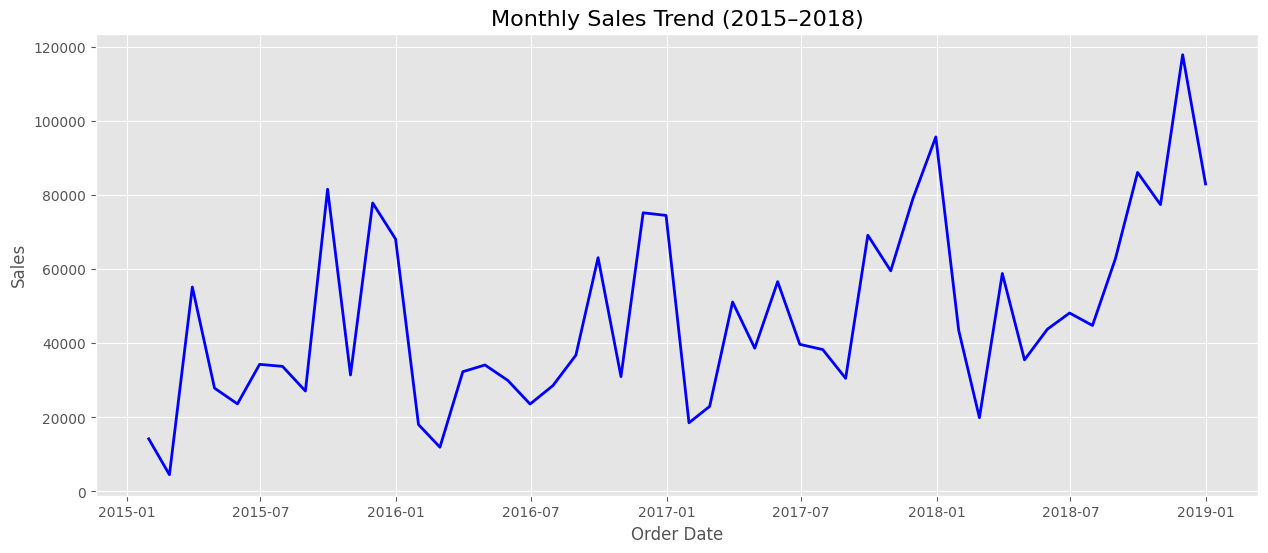

In [39]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2,
    color='blue'
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Time Series Decomposition

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

Plot All Components

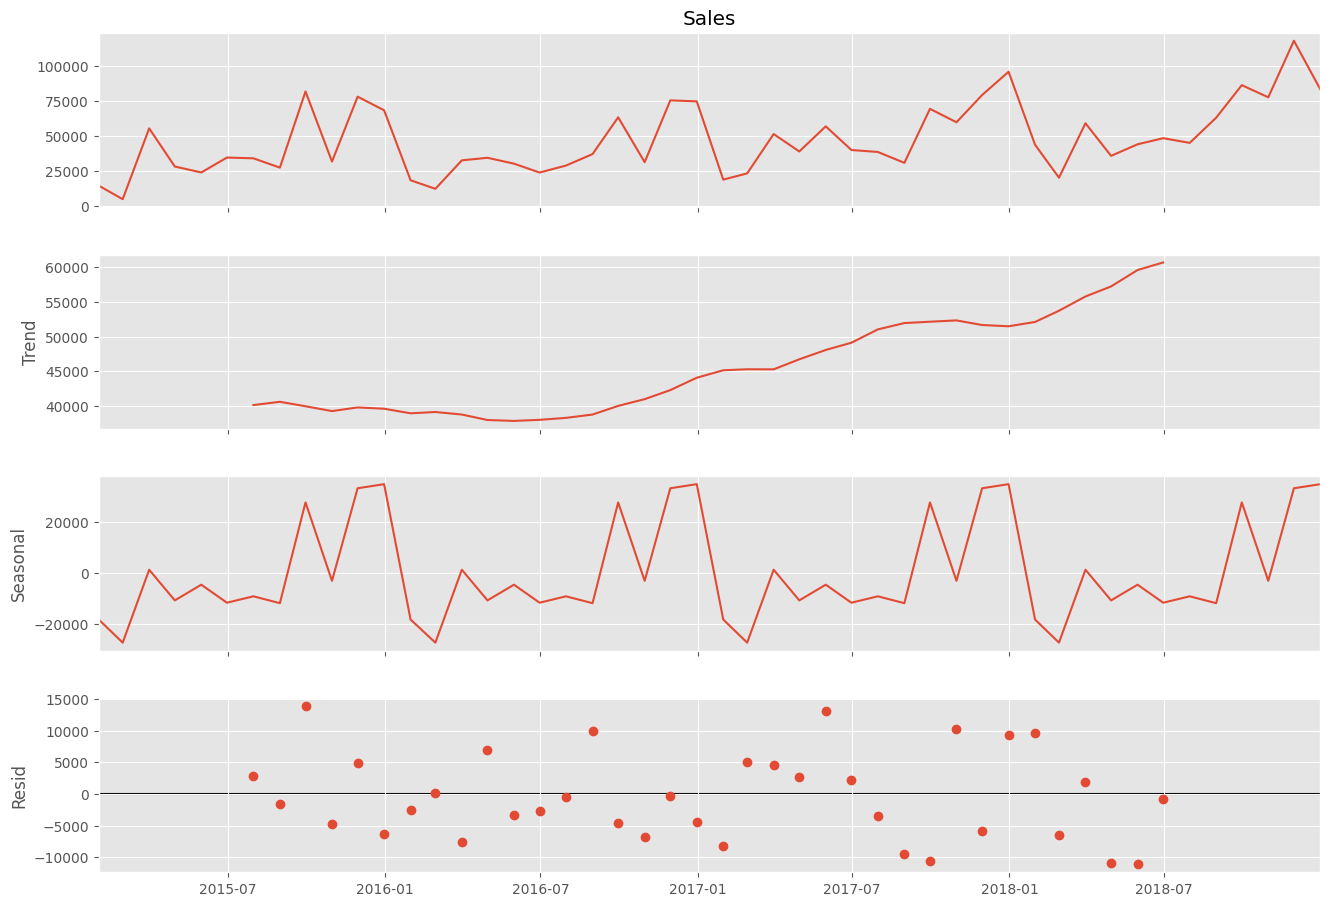

In [41]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

Perform the Augmented Dickey–Fuller (ADF) Test

In [42]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


Interpret the Result

In [43]:
if adf_result[1] <= 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

The time series is stationary.


Apply Differencing

In [44]:
monthly_sales_diff = monthly_sales.diff().dropna()

Plot the Differenced Series

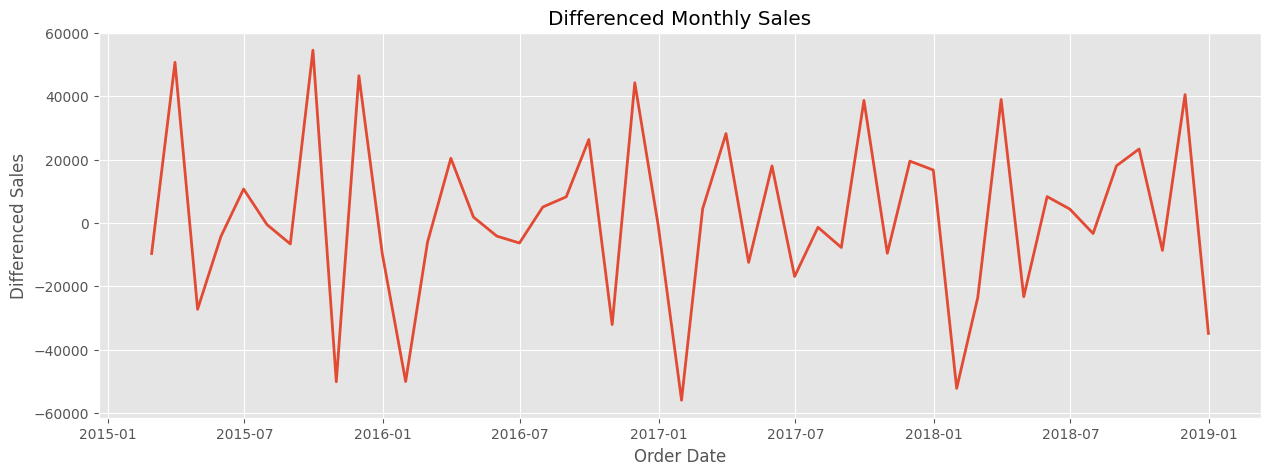

In [45]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales_diff,
    linewidth=2
)

plt.title("Differenced Monthly Sales")

plt.xlabel("Order Date")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

Re-run the ADF Test

In [46]:
adf_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])

if adf_diff[1] <= 0.05:
    print("The differenced series is stationary.")
else:
    print("The differenced series is still non-stationary.")

ADF Statistic : -8.727061830353268
p-value       : 3.2669175472796045e-14
The differenced series is stationary.


Task 3 — Sales Forecasting

Split the Data

In [47]:
# Monthly sales time series
monthly_sales = (
    superstore
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
)

# Train-Test Split
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training Months :", len(train))
print("Testing Months  :", len(test))

Training Months : 45
Testing Months  : 3


MODEL 1 — SARIMA

Train SARIMA

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    14:07:28   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

Predict Next 3 Months

In [49]:
sarima_forecast = sarima_fit.forecast(steps=3)

sarima_forecast

,predicted_mean
2018-10-31,60331.792101
2018-11-30,91458.220223
2018-12-31,97167.570951


Plot

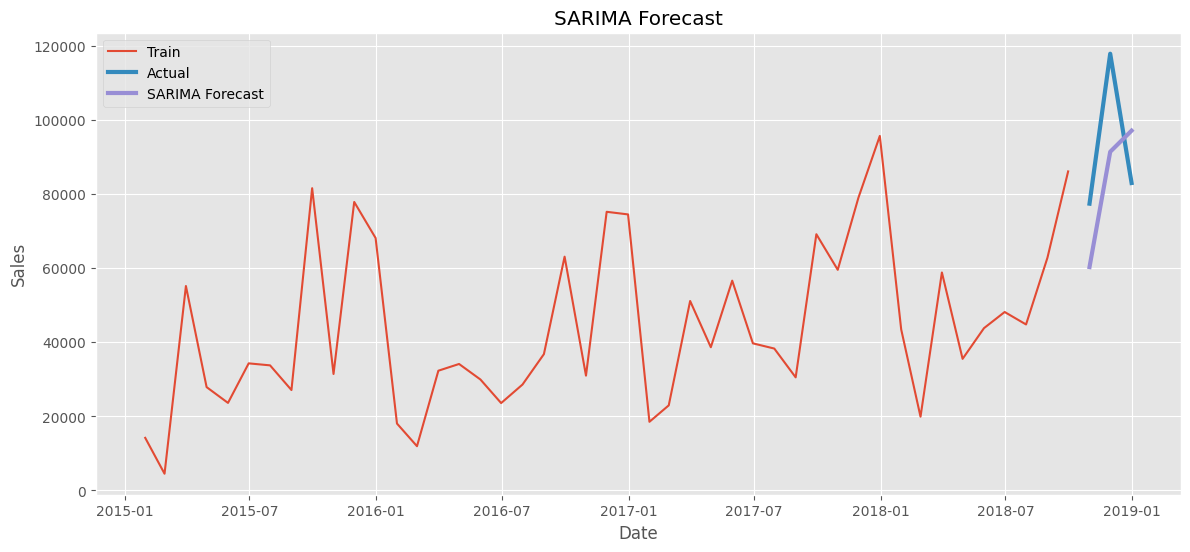

In [50]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual", linewidth=3)

plt.plot(test.index,
         sarima_forecast,
         label="SARIMA Forecast",
         linewidth=3)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Evaluate

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    sarima_forecast
)

print("MAE :", sarima_mae)

print("RMSE :", sarima_rmse)

print("MAPE :", sarima_mape)

MAE : 19244.485342503252
RMSE : 19950.070418779847
MAPE : 0.20526431983536764


In [52]:
print("SARIMA RESULTS")
print("MAE :", sarima_mae)
print("RMSE :", sarima_rmse)
print("MAPE :", sarima_mape)

SARIMA RESULTS
MAE : 19244.485342503252
RMSE : 19950.070418779847
MAPE : 0.20526431983536764


Model 2 — Prophet Forecasting

Prepare Data for Prophet

In [53]:
# Prepare data for Prophet
prophet_data = monthly_sales.reset_index()

prophet_data.columns = ['ds', 'y']

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Split Train and Test

In [54]:
train_prophet = prophet_data[:-3]

test_prophet = prophet_data[-3:]

Train Prophet Model

In [55]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

Create Future Dates

In [56]:
future = model.make_future_dataframe(
    periods=3,
    freq='ME'
)

Forecast

In [57]:
forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39344.801433,55000.803279
44,2018-09-30,86613.953271,78920.199315,95125.730874
45,2018-10-31,51318.943812,42977.340012,58984.869478
46,2018-11-30,90325.654736,81762.233881,98727.194439
47,2018-12-31,90041.084430,82262.167890,98658.975258


Plot Forecast

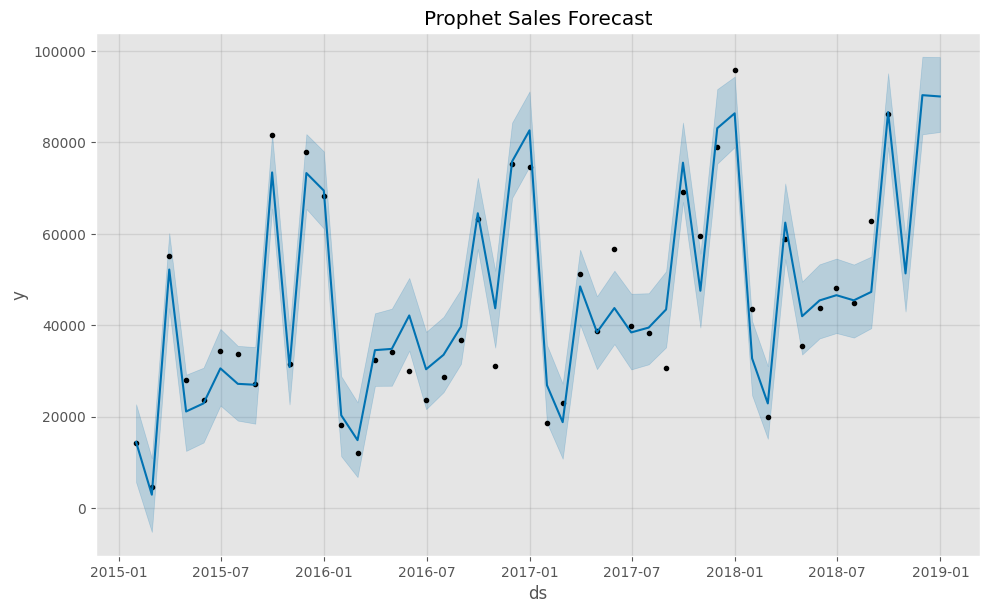

In [58]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.show()

Trend and Seasonality

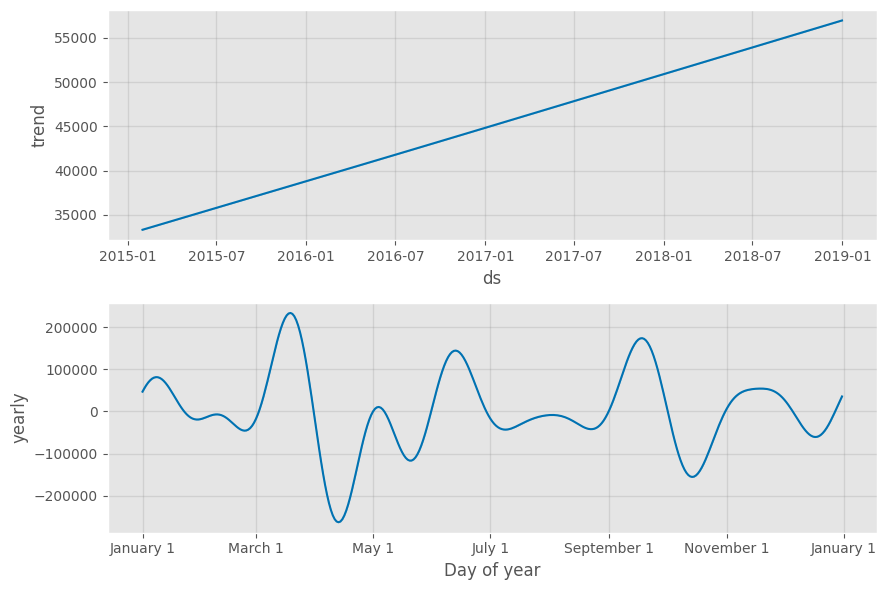

In [59]:
model.plot_components(forecast)

plt.show()

Extract Predictions

In [60]:
prophet_forecast = forecast.tail(3)['yhat'].values

prophet_forecast

array([51318.94381151, 90325.6547358 , 90041.08443015])

Evaluate

In [61]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

prophet_mae = mean_absolute_error(
    test_prophet['y'],
    prophet_forecast
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        prophet_forecast
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet['y'],
    prophet_forecast
)

print("MAE :", prophet_mae)

print("RMSE :", prophet_rmse)

print("MAPE :", prophet_mape)

MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 0.21864628287701435


Save the Results

In [62]:
print("PROPHET RESULTS")
print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

PROPHET RESULTS
MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 0.21864628287701435


Model 3 — XGBoost Time Series Forecasting

Create a DataFrame

In [63]:
# Create DataFrame from monthly sales
xgb_data = monthly_sales.reset_index()

xgb_data.columns = ['Date', 'Sales']

xgb_data.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Create Lag Features

In [64]:
# Lag Features
xgb_data['Lag_1'] = xgb_data['Sales'].shift(1)
xgb_data['Lag_2'] = xgb_data['Sales'].shift(2)
xgb_data['Lag_3'] = xgb_data['Sales'].shift(3)

Rolling Mean

In [65]:
xgb_data['Rolling_Mean_3'] = (
    xgb_data['Sales']
    .rolling(3)
    .mean()
)

Create Time Features

In [66]:
xgb_data['Month'] = xgb_data['Date'].dt.month
xgb_data['Quarter'] = xgb_data['Date'].dt.quarter
xgb_data['Year'] = xgb_data['Date'].dt.year

Remove Missing Values

In [67]:
xgb_data = xgb_data.dropna()

xgb_data.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


Select Features

In [68]:
features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_Mean_3',
    'Month',
    'Quarter',
    'Year'
]

X = xgb_data[features]

y = xgb_data['Sales']

Train-Test Split

In [69]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

Train the Model

In [70]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Predict

In [71]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([85865.91, 86567.86, 88749.48], dtype=float32)

Plot Results

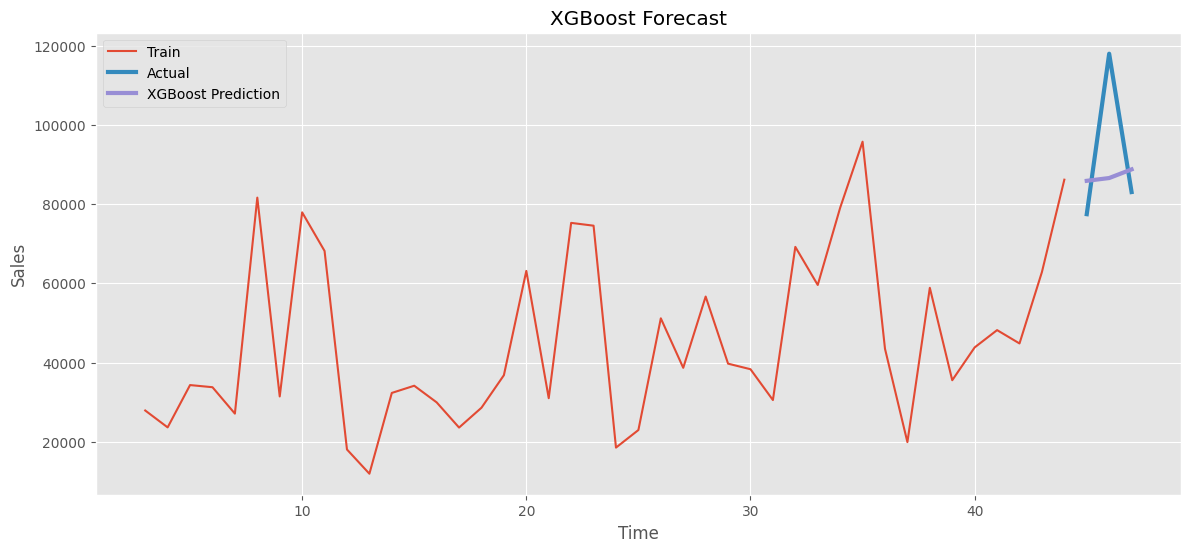

In [72]:
plt.figure(figsize=(14,6))

plt.plot(
    y_train.index,
    y_train,
    label='Train'
)

plt.plot(
    y_test.index,
    y_test,
    label='Actual',
    linewidth=3
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label='XGBoost Prediction',
    linewidth=3
)

plt.title("XGBoost Forecast")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Evaluate

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)

MAE : 15169.052812499998
RMSE : 19040.853878152575
MAPE : 0.14785267295148183


Compare All Three Models

In [74]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape]
})

comparison = comparison.sort_values(by="RMSE")

comparison

,Model,MAE,RMSE,MAPE
2,XGBoost,15169.052812,19040.853878,0.147853
0,SARIMA,19244.485343,19950.070419,0.205264
1,Prophet,20250.794428,22318.411366,0.218646


Select the Best Model

In [75]:
best_model = comparison.iloc[0]["Model"]

print("Best Model:", best_model)

Best Model: XGBoost


Task 4 – Product Category & Region Level Forecasting

Category-wise Monthly Sales

In [76]:
category_monthly = (
    superstore
    .groupby([
        pd.Grouper(key='Order Date', freq='ME'),
        'Category'
    ])['Sales']
    .sum()
    .reset_index()
)

category_monthly.head()

,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


Create Separate DataFrames

In [77]:
furniture = category_monthly[
    category_monthly['Category'] == 'Furniture'
]

technology = category_monthly[
    category_monthly['Category'] == 'Technology'
]

office = category_monthly[
    category_monthly['Category'] == 'Office Supplies'
]

Forecast Each Category

In [78]:
from prophet import Prophet

def prophet_forecast(df):

    data = df[['Order Date', 'Sales']].copy()
    data.columns = ['ds', 'y']

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(
        periods=3,
        freq='ME'
    )

    forecast = model.predict(future)

    return forecast

In [79]:
forecast_furniture = prophet_forecast(furniture)

forecast_technology = prophet_forecast(technology)

forecast_office = prophet_forecast(office)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Region-wise Monthly Sales

In [80]:
region_monthly = (
    superstore
    .groupby([
        pd.Grouper(key='Order Date', freq='ME'),
        'Region'
    ])['Sales']
    .sum()
    .reset_index()
)

Split Regions

In [81]:
west = region_monthly[
    region_monthly['Region'] == 'West'
]

east = region_monthly[
    region_monthly['Region'] == 'East'
]

Forecast Regions

In [82]:
forecast_west = prophet_forecast(west)

forecast_east = prophet_forecast(east)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Plot All Forecasts

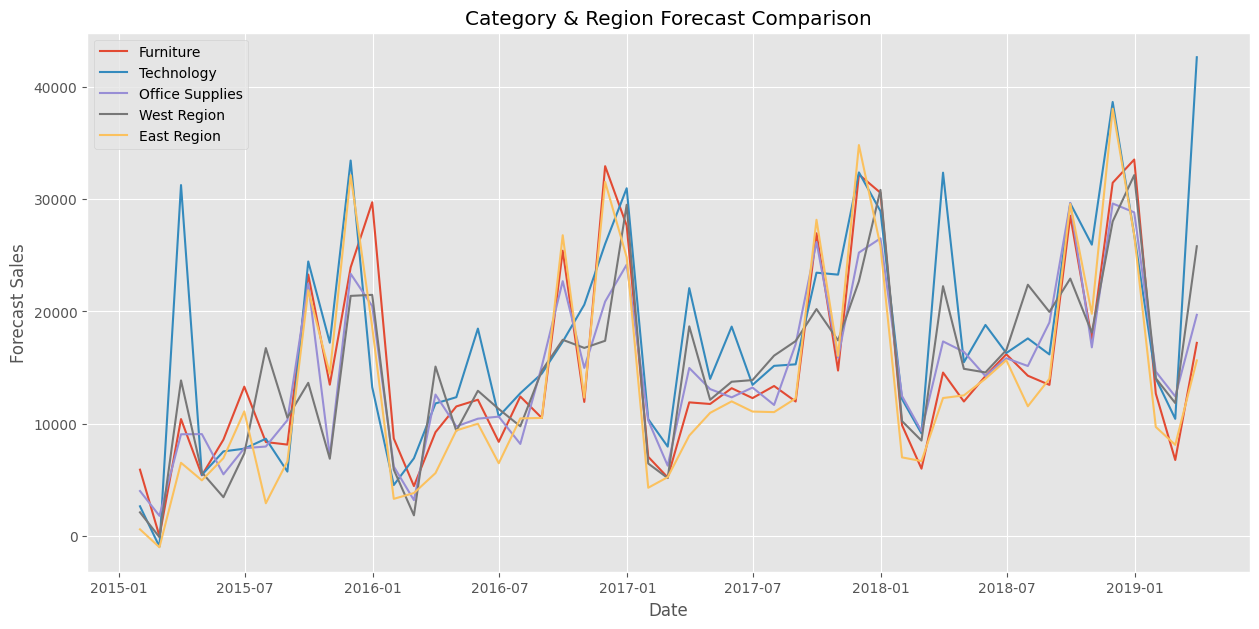

In [83]:
plt.figure(figsize=(15,7))

plt.plot(
    forecast_furniture['ds'],
    forecast_furniture['yhat'],
    label='Furniture'
)

plt.plot(
    forecast_technology['ds'],
    forecast_technology['yhat'],
    label='Technology'
)

plt.plot(
    forecast_office['ds'],
    forecast_office['yhat'],
    label='Office Supplies'
)

plt.plot(
    forecast_west['ds'],
    forecast_west['yhat'],
    label='West Region'
)

plt.plot(
    forecast_east['ds'],
    forecast_east['yhat'],
    label='East Region'
)

plt.legend()

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Forecast Sales")

plt.grid(True)

plt.show()

Compare Final Forecast Values

In [84]:
comparison = pd.DataFrame({
    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],
    "Forecast (Last Month)": [
        forecast_furniture['yhat'].iloc[-1],
        forecast_technology['yhat'].iloc[-1],
        forecast_office['yhat'].iloc[-1],
        forecast_west['yhat'].iloc[-1],
        forecast_east['yhat'].iloc[-1]
    ]
})

comparison.sort_values(
    by='Forecast (Last Month)',
    ascending=False
)

,Segment,Forecast (Last Month)
1,Technology,42639.488041
3,West,25805.336380
2,Office Supplies,19698.155527
0,Furniture,17201.015649
4,East,15639.421337


Task 5 – Anomaly Detection

Create Weekly Sales Data

In [85]:
# Weekly Sales
weekly_sales = (
    superstore
    .groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


Isolation Forest

In [86]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales['Anomaly'] = iso_model.fit_predict(
    weekly_sales[['Sales']]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


Plot Isolation Forest Anomalies

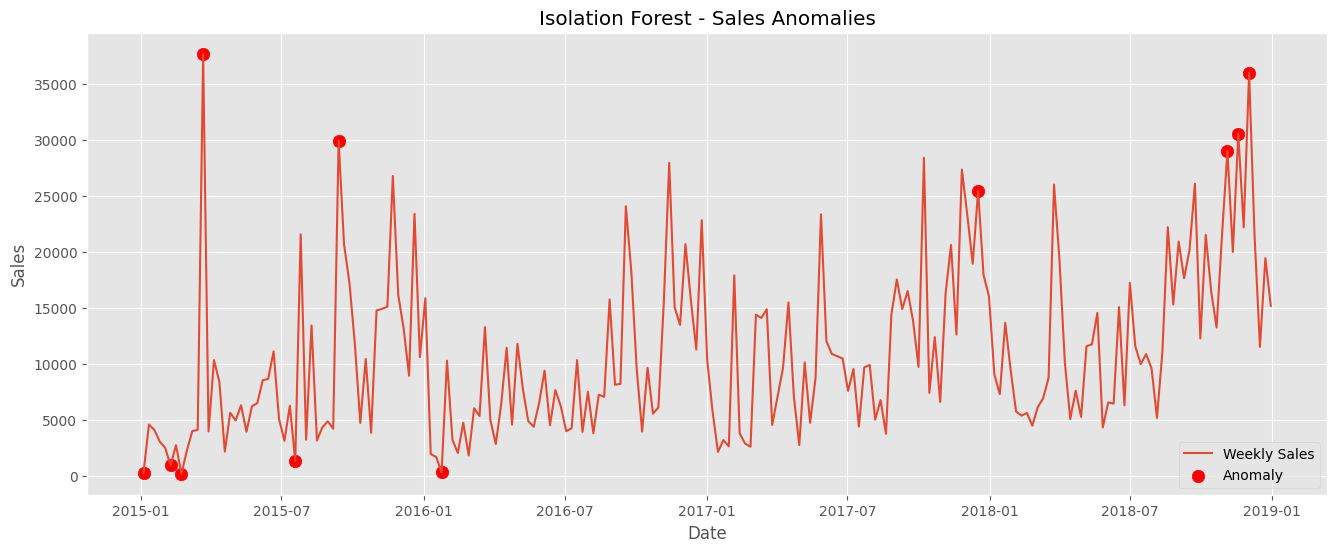

In [87]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    weekly_sales.loc[weekly_sales['Anomaly']==-1,'Order Date'],
    weekly_sales.loc[weekly_sales['Anomaly']==-1,'Sales'],
    color='red',
    s=80,
    label='Anomaly'
)

plt.title("Isolation Forest - Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Display Detected Anomalies

In [88]:
isolation_anomalies = weekly_sales[
    weekly_sales['Anomaly'] == -1
]

display(isolation_anomalies)

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


Z-Score Based Detection

In [89]:
weekly_sales['Rolling Mean'] = (
    weekly_sales['Sales']
    .rolling(4)
    .mean()
)

weekly_sales['Rolling Std'] = (
    weekly_sales['Sales']
    .rolling(4)
    .std()
)

Calculate Z-Score

In [90]:
weekly_sales['Z Score'] = (
    weekly_sales['Sales']
    - weekly_sales['Rolling Mean']
) / weekly_sales['Rolling Std']

Detect Anomalies

In [91]:
weekly_sales['Z Anomaly'] = (
    abs(weekly_sales['Z Score']) > 2
)

Plot Z-Score Anomalies

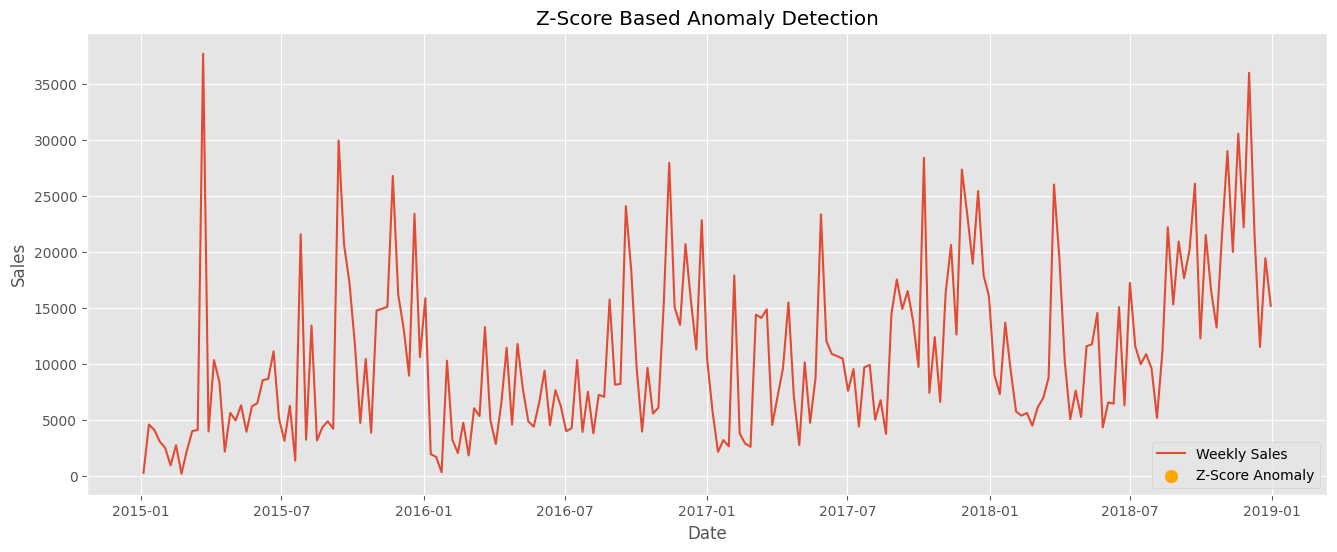

In [92]:
plt.figure(figsize=(16,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales['Z Anomaly'],
        'Order Date'
    ],
    weekly_sales.loc[
        weekly_sales['Z Anomaly'],
        'Sales'
    ],
    color='orange',
    s=80,
    label='Z-Score Anomaly'
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

Display Z-Score Anomalies

In [93]:
zscore_anomalies = weekly_sales[
    weekly_sales['Z Anomaly']
]

display(zscore_anomalies)

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z Anomaly


Compare Both Methods

In [94]:
print("Isolation Forest Anomalies :", len(isolation_anomalies))

print("Z-Score Anomalies :", len(zscore_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0


Task 6 – Product Demand Segmentation

Aggregate Data by Sub-Category

In [95]:
# Aggregate data by Sub-Category
product_data = (
    superstore.groupby('Sub-Category')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Avg_Order_Value=('Sales', 'mean'),
        Sales_Volatility=('Sales', 'std')
    )
    .reset_index()
)

product_data.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


Calculate Yearly Sales Growth

In [96]:
# Yearly sales by Sub-Category
yearly_sales = (
    superstore.groupby(['Sub-Category', 'Year'])['Sales']
    .sum()
    .reset_index()
)

# Pivot table
growth = yearly_sales.pivot(
    index='Sub-Category',
    columns='Year',
    values='Sales'
)

growth

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41735.3640,58240.9700
Appliances,15160.7150,23228.1790,26016.7870,40212.7220
Art,5897.5340,6091.6360,5890.6080,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,37476.7749,26275.4665,30024.2797
Chairs,77046.4400,70654.6730,81930.3450,93191.2730
Copiers,10849.7820,26179.4500,46319.4740,62899.3880
Envelopes,3844.5900,4448.2180,4456.6640,3378.5740
Fasteners,655.3880,545.2240,946.2740,855.0740


Calculate Growth Rate

In [97]:
# Growth Rate
growth['Growth_Rate'] = (
    (growth.iloc[:, -1] - growth.iloc[:, 0]) /
    growth.iloc[:, 0]
) * 100

growth_rate = growth[['Growth_Rate']].reset_index()

growth_rate.head()

Year,Sub-Category,Growth_Rate
0,Accessories,145.055961
1,Appliances,165.242912
2,Art,49.649531
3,Binders,65.778638
4,Bookcases,49.846598


Merge Features

In [98]:
product_data = product_data.merge(
    growth_rate,
    on='Sub-Category'
)

product_data.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,337.723800,145.055961
1,Appliances,104618.4030,227.926804,378.006735,165.242912
2,Art,26705.4100,34.019631,60.301752,49.649531
3,Binders,200028.7850,134.067550,568.099970,65.778638
4,Bookcases,113813.1987,503.598224,641.419280,49.846598


Prepare Features

In [99]:
features = [
    'Total_Sales',
    'Avg_Order_Value',
    'Sales_Volatility',
    'Growth_Rate'
]

X = product_data[features]

Scale Features

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Elbow Method

In [101]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

Plot Elbow Curve

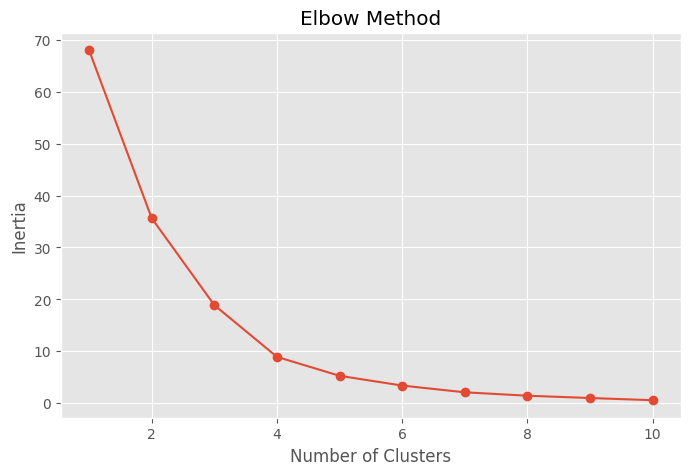

In [102]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

Apply K-Means

In [103]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data['Cluster'] = kmeans.fit_predict(X_scaled)

product_data.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
0,Accessories,164186.7000,217.178175,337.723800,145.055961,1
1,Appliances,104618.4030,227.926804,378.006735,165.242912,2
2,Art,26705.4100,34.019631,60.301752,49.649531,2
3,Binders,200028.7850,134.067550,568.099970,65.778638,1
4,Bookcases,113813.1987,503.598224,641.419280,49.846598,2


PCA Visualization

In [104]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

product_data['PCA1'] = pca_features[:,0]
product_data['PCA2'] = pca_features[:,1]

Plot Clusters

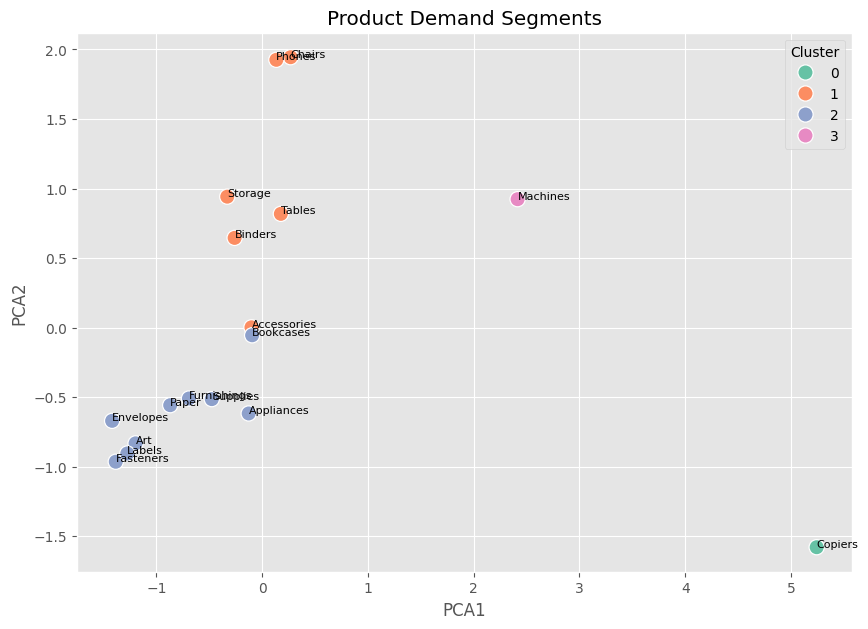

In [105]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product_data,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    s=120,
    palette='Set2'
)

for i in range(len(product_data)):
    plt.text(
        product_data['PCA1'][i],
        product_data['PCA2'][i],
        product_data['Sub-Category'][i],
        fontsize=8
    )

plt.title("Product Demand Segments")

plt.show()

Label the Clusters

In [106]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility",
    3: "Declining Demand"
}

product_data['Demand Segment'] = product_data['Cluster'].map(cluster_labels)

product_data

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PCA1,PCA2,Demand Segment
0,Accessories,164186.7000,217.178175,337.723800,145.055961,1,-0.101749,0.002518,Growing Demand
1,Appliances,104618.4030,227.926804,378.006735,165.242912,2,-0.128139,-0.616706,"Low Volume, High Volatility"
2,Art,26705.4100,34.019631,60.301752,49.649531,2,-1.197441,-0.831569,"Low Volume, High Volatility"
3,Binders,200028.7850,134.067550,568.099970,65.778638,1,-0.261117,0.645221,Growing Demand
4,Bookcases,113813.1987,503.598224,641.419280,49.846598,2,-0.095392,-0.054950,"Low Volume, High Volatility"
5,Chairs,322822.7310,531.833165,551.180296,20.954677,1,0.268112,1.943703,Growing Demand
6,Copiers,146248.0940,2215.880212,3216.185499,479.729510,0,5.242690,-1.578112,"High Volume, Stable Demand"
7,Envelopes,16128.0460,65.032444,85.170691,-12.121345,2,-1.419286,-0.669671,"Low Volume, High Volatility"
8,Fasteners,3001.9600,14.027850,12.466864,30.468364,2,-1.384998,-0.963733,"Low Volume, High Volatility"
9,Furnishings,89212.0180,95.823865,148.421490,106.824969,2,-0.692807,-0.509188,"Low Volume, High Volatility"


Install Libraries

In [107]:
!pip install -q streamlit plotly prophet pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 54.1 MB/s eta 0:00:00


Create Pages Folder

In [108]:
import os

os.makedirs("pages", exist_ok=True)

print("Pages folder created successfully!")

Pages folder created successfully!


Create app.py

In [109]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="Sales Forecasting Dashboard",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Sales Forecasting & Demand Intelligence System")

st.markdown("""
### Welcome

Use the navigation panel on the left to explore:

- 📈 Sales Overview
- 🔮 Forecast Explorer
- 🚨 Anomaly Report
- 📦 Product Demand Segments
""")

st.success("Dashboard Loaded Successfully")

Writing app.py


Page 1 (Sales Overview)

In [110]:
%%writefile pages/1_Sales_Overview.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.title("📈 Sales Overview Dashboard")

df = pd.read_csv("train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

# KPIs
col1,col2,col3 = st.columns(3)

col1.metric("Total Sales",f"${df['Sales'].sum():,.2f}")
col2.metric("Total Orders",len(df))
col3.metric("Average Sales",f"${df['Sales'].mean():,.2f}")

# Yearly Sales
yearly=df.groupby("Year")["Sales"].sum().reset_index()

fig=px.bar(
    yearly,
    x="Year",
    y="Sales",
    title="Yearly Sales"
)

st.plotly_chart(fig,use_container_width=True)

# Monthly Trend
monthly=df.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"].sum().reset_index()

fig=px.line(
    monthly,
    x="Order Date",
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

st.plotly_chart(fig,use_container_width=True)

# Category Sales
category=df.groupby("Category")["Sales"].sum().reset_index()

fig=px.pie(
    category,
    names="Category",
    values="Sales",
    title="Sales by Category"
)

st.plotly_chart(fig,use_container_width=True)

Writing pages/1_Sales_Overview.py


Page 2 (Forecast Explorer)

In [111]:
%%writefile pages/2_Forecast_Explorer.py

import streamlit as st
import pandas as pd
from prophet import Prophet
import plotly.express as px

st.title("🔮 Forecast Explorer")

df=pd.read_csv("train.csv")

df["Order Date"]=pd.to_datetime(df["Order Date"],dayfirst=True)

monthly=df.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"].sum().reset_index()

monthly.columns=["ds","y"]

model=Prophet()

model.fit(monthly)

future=model.make_future_dataframe(periods=3,freq="ME")

forecast=model.predict(future)

fig=px.line(
    forecast,
    x="ds",
    y="yhat",
    title="3 Month Sales Forecast"
)

st.plotly_chart(fig,use_container_width=True)

st.dataframe(
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)
)

Writing pages/2_Forecast_Explorer.py


Page 3 (Anomaly Report)

In [112]:
%%writefile pages/3_Anomaly_Report.py

import streamlit as st
import pandas as pd
from sklearn.ensemble import IsolationForest
import plotly.express as px

st.title("🚨 Sales Anomaly Report")

df=pd.read_csv("train.csv")

df["Order Date"]=pd.to_datetime(df["Order Date"],dayfirst=True)

weekly=df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"].sum().reset_index()

model=IsolationForest(
contamination=0.05,
random_state=42
)

weekly["Anomaly"]=model.fit_predict(weekly[["Sales"]])

fig=px.line(
weekly,
x="Order Date",
y="Sales",
title="Weekly Sales"
)

fig.add_scatter(
x=weekly[weekly["Anomaly"]==-1]["Order Date"],
y=weekly[weekly["Anomaly"]==-1]["Sales"],
mode="markers",
name="Anomaly"
)

st.plotly_chart(fig,use_container_width=True)

st.dataframe(
weekly[weekly["Anomaly"]==-1]
)

Writing pages/3_Anomaly_Report.py


Page 4 (Product Segments)

In [113]:
%%writefile pages/4_Product_Segments.py

import streamlit as st
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px

st.title("📦 Product Demand Segments")

df=pd.read_csv("train.csv")

cluster=df.groupby("Sub-Category").agg(
Sales=("Sales","sum"),
Profit=("Profit","sum"),
Quantity=("Quantity","sum")
).reset_index()

X=cluster[["Sales","Profit","Quantity"]]

X=StandardScaler().fit_transform(X)

kmeans=KMeans(
n_clusters=4,
random_state=42,
n_init=10
)

cluster["Cluster"]=kmeans.fit_predict(X)

pca=PCA(n_components=2)

points=pca.fit_transform(X)

cluster["PCA1"]=points[:,0]

cluster["PCA2"]=points[:,1]

fig=px.scatter(
cluster,
x="PCA1",
y="PCA2",
color=cluster["Cluster"].astype(str),
hover_name="Sub-Category"
)

st.plotly_chart(fig,use_container_width=True)

st.dataframe(cluster)

Writing pages/4_Product_Segments.py


Create requirements.txt

In [114]:
%%writefile requirements.txt

streamlit
pandas
numpy
plotly
prophet
scikit-learn
matplotlib
statsmodels
xgboost

Writing requirements.txt


Run Streamlit

In [115]:
!streamlit run app.py &>/content/log.txt &